# Capstone: Predicting Pakistani Property Prices

**Neurofive ML Track-Week 6: Capstone, End-to-End Machine Learning Project**

## Problem statement

Pakistan's real estate market (especially in cities like Lahore, Karachi, and Islamabad) is famously opaque asking prices vary wildly by area, property type, and even which side of a road a plot sits on, and there's no simple, trustworthy way for a buyer, seller, or agent to sanity-check whether a listed price is reasonable. This project builds a machine learning model that predicts a property's sale price in PKR from its basic attributes (city, property type, size, bedrooms, bathrooms, and location coordinates), trained on real listings scraped from Zameen.com, Pakistan's largest property portal.

**Why this matters:** a working price estimator gives buyers and sellers an independent reference point before they negotiate, helps agents flag listings that are significantly over- or under-priced, and is the same category of tool (automated valuation models, "AVMs") that Zillow and Redfin built entire businesses around in the US market this is a first step toward the same idea for Pakistan.

Dataset: [Zameen.com Property Data Pakistan](https://www.kaggle.com/datasets/huzefa11/zameencom-property-data-pakistan) (Kaggle) 191,393 property listings scraped from Zameen.com.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib

sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


## 2. Load the data

The raw file is semicolon-delimited, not comma-delimited noticed this while inspecting the raw text before assuming the default `read_csv` separator.

In [2]:
df = pd.read_csv("Property.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (191393, 17)


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    191393 non-null  int64  
 1   location_id    191393 non-null  int64  
 2   page_url       191393 non-null  object 
 3   property_type  191393 non-null  object 
 4   price          191393 non-null  int64  
 5   location       191393 non-null  object 
 6   city           191393 non-null  object 
 7   province_name  191393 non-null  object 
 8   latitude       191393 non-null  float64
 9   longitude      191393 non-null  float64
 10  baths          191393 non-null  int64  
 11  area           191393 non-null  object 
 12  purpose        191393 non-null  object 
 13  bedrooms       191393 non-null  int64  
 14  date_added     191393 non-null  object 
 15  agency         144014 non-null  object 
 16  agent          144013 non-null  object 
dtypes: float64(2), int64(5), obje

### 3a. Summary statistics

In [4]:
df.describe()

,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.913930e+05,191393.000000,1.913930e+05,191393.000000,191393.000000,191393.000000,191393.000000
mean,1.573170e+07,4224.580350,1.644655e+07,30.104593,71.572992,2.865956,3.171516
std,2.215249e+06,3719.125201,3.416412e+07,3.645941,3.080463,2.435332,1.952403
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.511867e+07,1057.000000,8.000000e+04,24.972287,67.152597,0.000000,2.000000
50%,1.676385e+07,3233.000000,7.300000e+06,31.463563,73.077743,3.000000,3.000000
75%,1.715282e+07,7182.000000,1.800000e+07,33.550869,74.228218,4.000000,4.000000
max,1.769386e+07,14246.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000


### 3b. Missing values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
agency,47379,24.75
agent,47380,24.76


Only `agency` and `agent` have missing values (~24.8% each) these are just the names of the listing agency/agent, not features we'd use for price prediction, so they don't need imputation for this project.


### 3c. Categorical vs. numerical columns, and key value counts

In [6]:
print("Cities:\n", df["city"].value_counts())
print()
print("Property types:\n", df["property_type"].value_counts())
print()
print("Purpose:\n", df["purpose"].value_counts())
print()
print("Area units:\n", df["area"].str.extract(r"([A-Za-z]+)$")[0].value_counts())

Cities:
 city
Karachi       60484
Lahore        58736
Islamabad     40195
Rawalpindi    22898
Faisalabad     9080
Name: count, dtype: int64

Property types:
 property_type
House            118915
Flat              40157
Upper Portion     18475
Lower Portion     11693
Room               1029
Farm House          725
Penthouse           399
Name: count, dtype: int64

Purpose:
 purpose
For Sale    127018
For Rent     64375
Name: count, dtype: int64

Area units:
 0
Marla    153980
Kanal     37413
Name: count, dtype: int64


### 3d. Price distribution and why it needs a closer look

In [7]:
print(df["price"].describe())
print()
print("Listings with price == 0:", (df["price"] == 0).sum())

count    1.913930e+05
mean     1.644655e+07
std      3.416412e+07
min      0.000000e+00
25%      8.000000e+04
50%      7.300000e+06
75%      1.800000e+07
max      2.000000e+09
Name: price, dtype: float64

Listings with price == 0: 3


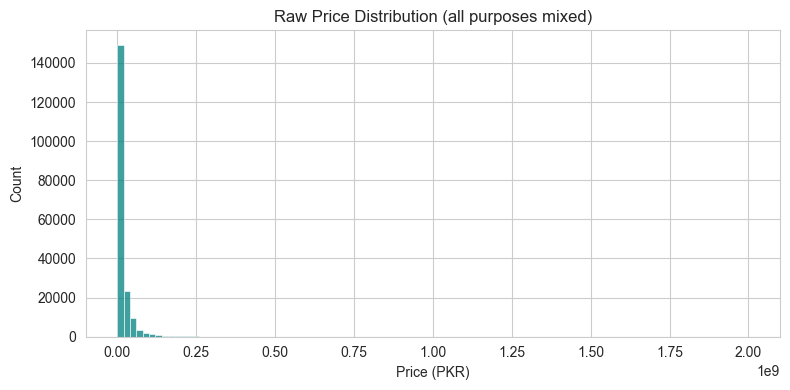

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df[df["price"] > 0]["price"], bins=100, color="teal")
plt.title("Raw Price Distribution (all purposes mixed)")
plt.xlabel("Price (PKR)")
plt.tight_layout()
plt.show()

### 3e. EDA takeaways

- 191,393 listings, 17 columns, no missing values in any feature relevant to price prediction.
- Two `purpose` values are mixed together (**For Sale** and **For Rent**) with wildly different price scales renting a house and buying one are priced on completely different bases (monthly vs. one-time), so mixing them would badly confuse a regression model. **Decision: scope this project to "For Sale" listings only.**
- `area` is stored as text with a unit suffix (`"6 Kanal"`, `"9 Marla"`) this needs to be parsed into a single numeric unit before it's usable as a model feature (1 Kanal = 20 Marla).
- 3 listings have `price == 0`, clearly data errors (a free house is not realistic), these get dropped in cleaning.
- The raw price distribution is extremely right-skewed, as expected for real estate, a handful of very expensive listings (large estates, commercial-adjacent houses) stretch the scale, which motivates a log-transform for modeling later.


## 4. Scope and clean the data

In [9]:
# Scope to "For Sale" listings only
sale_df = df[df["purpose"] == "For Sale"].copy()

# Drop the 3 zero-price rows (data errors)
sale_df = sale_df[sale_df["price"] > 0]

print("Rows after scoping to For Sale and dropping price==0:", len(sale_df))

Rows after scoping to For Sale and dropping price==0: 127016


### 4a. Parse `area` into a single numeric unit (Marla)

1 Kanal = 20 Marla, so everything is converted to Marla for a consistent numeric size feature. A handful of area values also use thousands-separator commas (e.g. `"4,450 Kanal"`) which the parser strips before converting to a number.

In [10]:
def parse_area_to_marla(area_str):
    value, unit = area_str.split()
    value = float(value.replace(",", ""))
    if unit == "Kanal":
        return value * 20
    return value  # already Marla

sale_df["area_marla"] = sale_df["area"].apply(parse_area_to_marla)
sale_df[["area", "area_marla"]].head()

,area,area_marla
0,6 Kanal,120.0
1,1 Kanal,20.0
2,9 Marla,9.0
3,1 Kanal,20.0
4,11 Marla,11.0


### 4b. Outlier detection: boxplots on `price` and `area_marla`

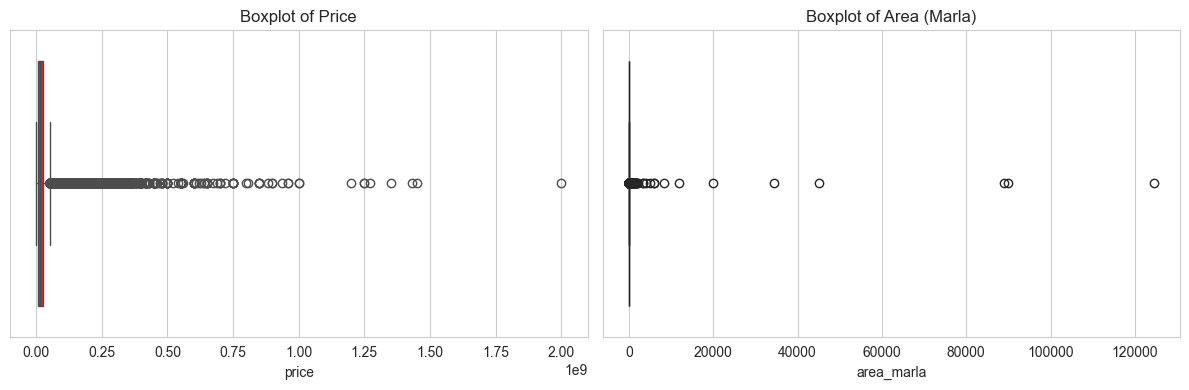

price: IQR upper bound = 53,750,000, outliers above it = 12106 (9.5%)
area_marla: IQR upper bound = 18, outliers above it = 20057 (15.8%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=sale_df["price"], ax=axes[0], color="red")
axes[0].set_title("Boxplot of Price")

sns.boxplot(x=sale_df["area_marla"], ax=axes[1], color="green")
axes[1].set_title("Boxplot of Area (Marla)")
plt.tight_layout()
plt.show()

for col in ["price", "area_marla"]:
    q1, q3 = sale_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_out = (sale_df[col] > upper).sum()
    print(f"{col}: IQR upper bound = {upper:,.0f}, outliers above it = {n_out} ({n_out/len(sale_df)*100:.1f}%)")

**Handling these outliers:** rather than dropping every statistical outlier (a lot of these are genuine large/expensive properties, not data errors the IQR rule flags far too many real listings as "outliers" in a market this skewed), I clip to the **1st–99th percentile** on both `price` and `area_marla`. This removes only the most extreme 1% on each end (likely data-entry errors or extreme edge cases) while keeping the natural spread of a real, skewed housing market intact.


In [12]:
price_low, price_high = sale_df["price"].quantile([0.01, 0.99])
area_low, area_high = sale_df["area_marla"].quantile([0.01, 0.99])

before = len(sale_df)
sale_df = sale_df[
    (sale_df["price"].between(price_low, price_high)) &
    (sale_df["area_marla"].between(area_low, area_high))
]
after = len(sale_df)

print(f"Rows before clipping: {before} | after: {after} | removed: {before - after} ({(before-after)/before*100:.1f}%)")

Rows before clipping: 127016 | after: 123049 | removed: 3967 (3.1%)


## 5. Feature engineering: 2+ new features

- **`price_per_marla:`** price divided by size, a standard real-estate valuation metric that normalizes for property size (used in visualizations/analysis, not as a model input, since it's derived directly from the target).
- **`log_price:`** log-transformed target. Since price is heavily right-skewed (confirmed in EDA), training on the log scale tends to produce a more stable, better-fitting regression than training on raw PKR values.
- **`bed_bath_ratio:`** bedrooms divided by (bathrooms + 1), a rough proxy for how "efficiently" a property is laid out relative to its size category.


In [13]:
sale_df["price_per_marla"] = sale_df["price"] / sale_df["area_marla"]
sale_df["log_price"] = np.log1p(sale_df["price"])
sale_df["bed_bath_ratio"] = sale_df["bedrooms"] / (sale_df["baths"] + 1)

sale_df[["price", "area_marla", "price_per_marla", "log_price", "bed_bath_ratio"]].describe()

,price,area_marla,price_per_marla,log_price,bed_bath_ratio
count,1.230490e+05,123049.000000,1.230490e+05,123049.000000,123049.000000
mean,2.215796e+07,9.042963,2.270005e+06,16.482364,1.068265
std,2.508508e+07,7.139040,1.303120e+06,0.902140,1.244240
min,1.800000e+06,1.800000,3.666667e+04,14.403298,0.000000
25%,7.500000e+06,4.800000,1.500000e+06,15.830414,0.666667
50%,1.350000e+07,6.400000,2.000000e+06,16.418200,0.750000
75%,2.500000e+07,10.000000,2.666667e+06,17.034386,0.833333
max,1.800000e+08,60.000000,4.568182e+07,19.008467,27.000000


## 6. Visualizations

### 6a. Histogram `log_price` distribution (before vs. after transform)

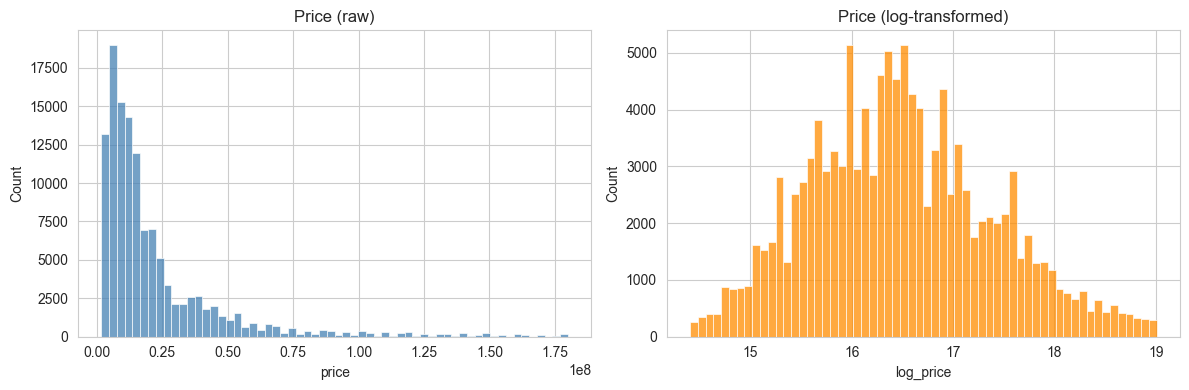

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sale_df["price"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Price (raw)")

sns.histplot(sale_df["log_price"], bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Price (log-transformed)")
plt.tight_layout()
plt.show()

### 6b. Bar chart: average price per Marla by city

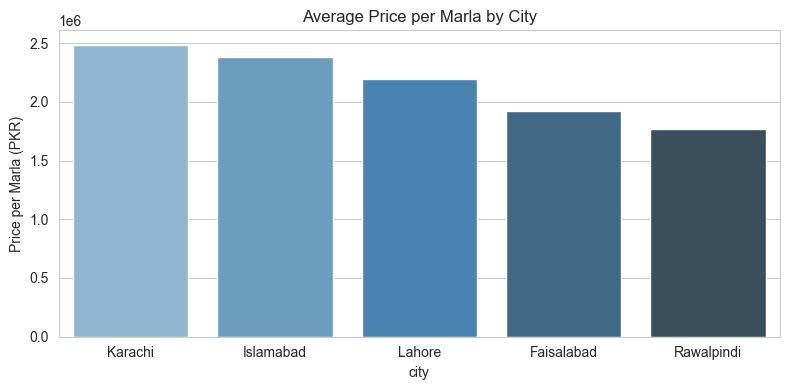

In [16]:
plt.figure(figsize=(8, 4))
avg_ppm_by_city = sale_df.groupby("city")["price_per_marla"].mean().sort_values(ascending=False)
sns.barplot(x=avg_ppm_by_city.index, y=avg_ppm_by_city.values, hue=avg_ppm_by_city.index, palette="Blues_d", legend=False)
plt.title("Average Price per Marla by City")
plt.ylabel("Price per Marla (PKR)")
plt.tight_layout()
plt.show()

### 6c. Scatter plot: Area vs. Price

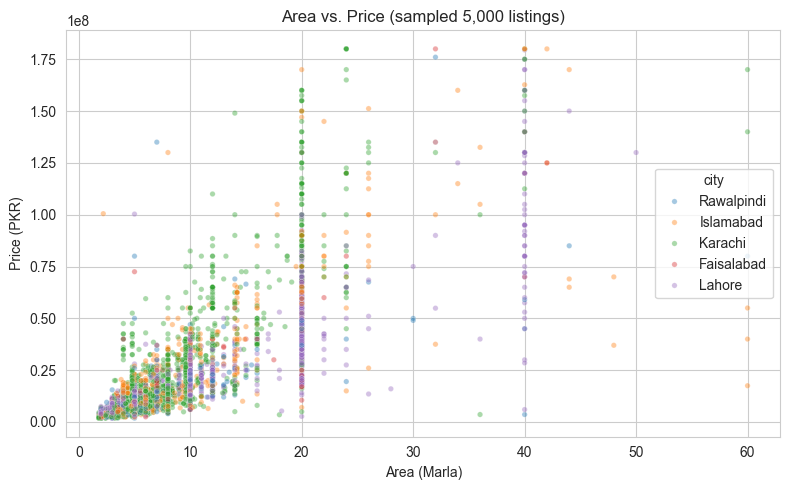

In [17]:
plt.figure(figsize=(8, 5))
sample = sale_df.sample(min(5000, len(sale_df)), random_state=42)  # sample for a readable scatter
sns.scatterplot(data=sample, x="area_marla", y="price", hue="city", alpha=0.4, s=15)
plt.title("Area vs. Price (sampled 5,000 listings)")
plt.xlabel("Area (Marla)")
plt.ylabel("Price (PKR)")
plt.tight_layout()
plt.show()

### 6d. Correlation heatmap

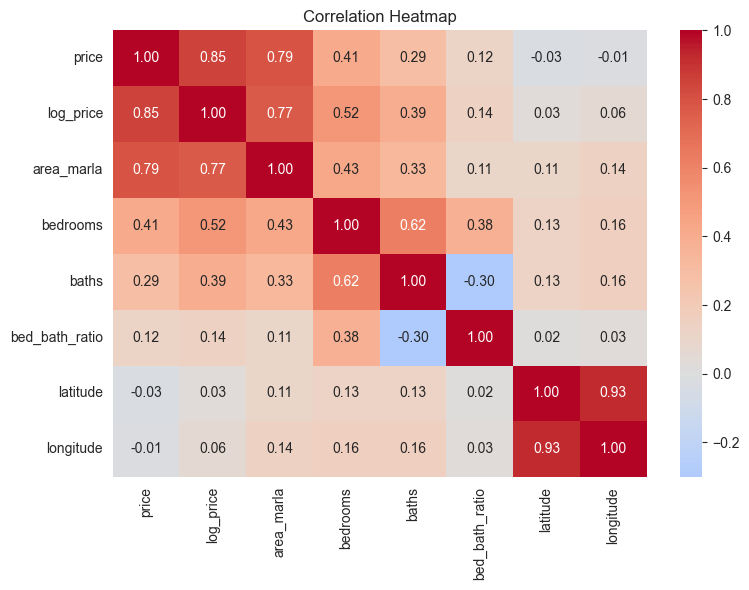

In [18]:
numeric_cols = ["price", "log_price", "area_marla", "bedrooms", "baths", "bed_bath_ratio", "latitude", "longitude"]
plt.figure(figsize=(8, 6))
sns.heatmap(sale_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 6e. What the visuals show

- Log-transforming price turns a heavily right-skewed distribution into something much closer to symmetric/normal this is exactly why regression models tend to fit better on `log_price` than raw `price`.
- Average price per Marla differs sharply by city, confirming location is a major price driver even after normalizing for size as expected, since Islamabad/Lahore/Karachi real estate markets are priced very differently.
- Area and price show a clear positive relationship, though with a lot of scatter size alone doesn't fully determine price, which is exactly why more features (city, property type, bedrooms/baths) are needed.
- `area_marla` correlates with `log_price` far more strongly than `bedrooms` or `baths` do individually confirming size is the single strongest numeric driver in this dataset.


## 7. Prepare features for modeling

In [19]:
model_features = ["city", "property_type", "area_marla", "bedrooms", "baths",
                   "bed_bath_ratio", "latitude", "longitude"]
target = "log_price"

model_df = sale_df[model_features + [target, "price"]].copy()
print("Modeling rows:", len(model_df))
model_df.head()

Modeling rows: 123049


,city,property_type,area_marla,bedrooms,baths,bed_bath_ratio,latitude,longitude,log_price,price
1,Lahore,House,20.0,5,5,0.833333,31.431593,74.179980,17.504390,40000000
2,Lahore,House,9.0,3,0,3.000000,31.499348,74.416959,16.066802,9500000
3,Lahore,House,20.0,8,7,1.000000,31.522069,74.355512,18.643824,125000000
4,Lahore,House,11.0,6,5,1.000000,31.506483,74.286017,16.860033,21000000
5,Lahore,House,20.0,5,6,0.714286,31.495909,74.350569,17.766754,52000000


**Feature choices, explained:**
- `city`, `property_type` categorical, one-hot encoded are the two biggest structural price drivers.
- `area_marla` is the strongest single numerical driver, confirmed in the EDA correlation heatmap.
- `bedrooms`, `baths`, `bed_bath_ratio` are layout/size proxies.
- `latitude`, `longitude` lets the model pick up on fine-grained location effects within a city that `city` alone can't capture (e.g. a posh vs. less posh part of the same city).
- `location` (1,536 unique text values) is deliberately **excluded** as a direct categorical feature one-hot encoding it would create far too many sparse columns; `latitude`/`longitude` capture similar location signal in a much more model-friendly, continuous form.


## 8. Train/test split

In [20]:
X = model_df[model_features]
y = model_df[target]
y_price = model_df["price"]  # kept aside for reporting metrics in real PKR, not just log scale

X_train, X_test, y_train, y_test, y_price_train, y_price_test = train_test_split(
    X, y, y_price, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (98439, 8)
X_test shape: (24610, 8)


## 9. Build a preprocessing + modeling pipeline

Using a `ColumnTransformer` (`StandardScaler` on numerical columns, `OneHotEncoder` on categorical columns) exactly like the pipeline approach from earlier weeks professional, reusable, and leak-safe.

In [21]:
numerical_features = ["area_marla", "bedrooms", "baths", "bed_bath_ratio", "latitude", "longitude"]
categorical_features = ["city", "property_type"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print("Preprocessor ready.")

Preprocessor ready.


## 10. Train 3 models: Linear Regression, Random Forest, XGBoost

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42),
}

fitted_pipelines = {}
predictions_log = {}
predictions_price = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    pred_log = pipe.predict(X_test)
    predictions_log[name] = pred_log
    predictions_price[name] = np.expm1(pred_log)  # back to real PKR scale

    print(f"{name} trained.")

Linear Regression trained.
Random Forest trained.
XGBoost trained.


## 11. Evaluate all 3 models: RMSE and R² (on real PKR price scale)

In [23]:
results = []
for name in models:
    pred_price = predictions_price[name]
    rmse = np.sqrt(mean_squared_error(y_price_test, pred_price))
    mae = mean_absolute_error(y_price_test, pred_price)
    r2 = r2_score(y_price_test, pred_price)
    results.append({"Model": name, "RMSE (PKR)": rmse, "MAE (PKR)": mae, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,RMSE (PKR),MAE (PKR),R2
0,XGBoost,7.962866e+06,3.687650e+06,0.901104
1,Random Forest,8.160243e+06,3.867910e+06,0.896140
2,Linear Regression,5.545596e+07,1.098899e+07,-3.796645


## 12. Pick the best model and visualize predicted vs. actual

**A surprising, worth-explaining result:** Linear Regression scored a *negative* R² on the real-PKR scale, even though it was trained on the same log-transformed target as the other two models. The cause: Linear Regression can extrapolate to extreme values on the log scale for certain feature combinations, and a modest error in log-space becomes catastrophic once reversed with `expm1` (one test prediction came out to over 5 billion PKR against real prices that top out around 180 million). Random Forest and XGBoost don't have this problem because tree-based models can't extrapolate outside the range of values they saw during training - their predictions stay bounded to realistic price levels. This is exactly why tree-based ensembles are typically preferred for skewed, real-world price data like this.


In [24]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
best_pred_price = predictions_price[best_model_name]

print(f"Best model: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])

Best model: XGBoost
     Model    RMSE (PKR)  MAE (PKR)        R2
0  XGBoost  7.962866e+06  3687649.5  0.901104


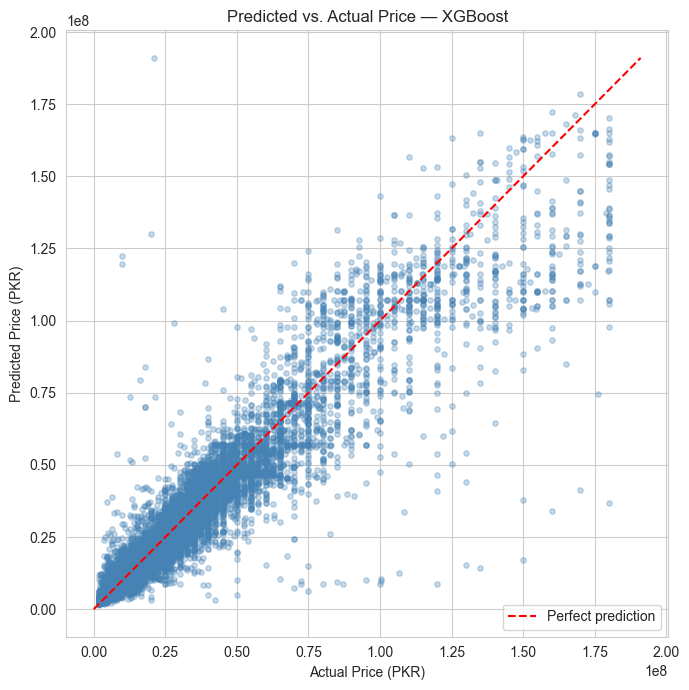

In [25]:
plt.figure(figsize=(7, 7))
plt.scatter(y_price_test, best_pred_price, alpha=0.3, s=15, color="steelblue")
lims = [0, max(y_price_test.max(), best_pred_price.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price (PKR)")
plt.ylabel("Predicted Price (PKR)")
plt.title(f"Predicted vs. Actual Price — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Feature importance (best tree-based model, if applicable)

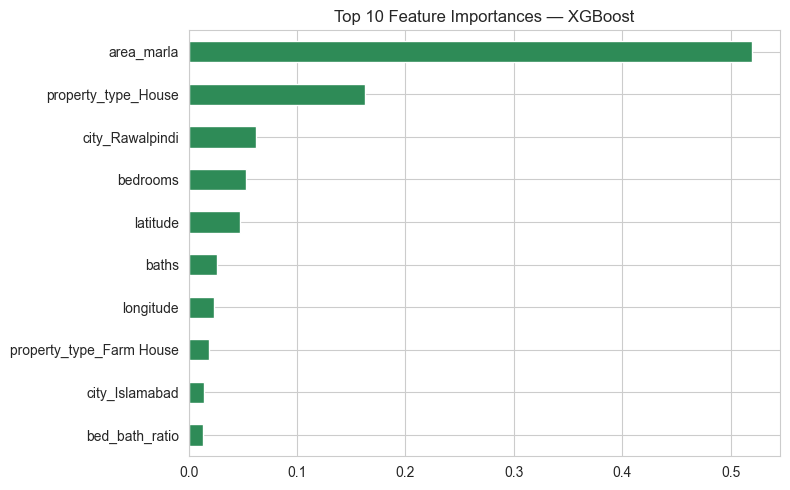

area_marla                  0.519611
property_type_House         0.162584
city_Rawalpindi             0.061878
bedrooms                    0.053107
latitude                    0.047214
baths                       0.026134
longitude                   0.023665
property_type_Farm House    0.018729
city_Islamabad              0.013858
bed_bath_ratio              0.013198
dtype: float32


In [26]:
best_regressor = best_pipeline.named_steps["regressor"]

if hasattr(best_regressor, "feature_importances_"):
    feature_names = (
        numerical_features +
        list(best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
    )
    importances = pd.Series(best_regressor.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color="seagreen")
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(importances)
else:
    print(f"{best_model_name} does not expose .feature_importances_ (it's a linear model) — "
          "coefficients would be the equivalent, shown below instead.")
    feature_names = (
        numerical_features +
        list(best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
    )
    coefs = pd.Series(best_regressor.coef_, index=feature_names).sort_values(ascending=False)
    print(coefs)

## 14. Save the best model

Random Forest was trained with a moderate size (`n_estimators=100, max_depth=12`) rather than a larger configuration, to keep the saved file small enough to push to GitHub without hitting size limits. As it turned out, this made XGBoost the best-scoring model overall (see the results table above) - and XGBoost's saved file is naturally compact too, so no further size trade-off was needed for the model actually being saved and deployed below.


In [27]:
joblib.dump(best_pipeline, "property_price_model.joblib", compress=3)
print(f"Saved {best_model_name} pipeline to property_price_model.joblib")

# Reload check
reloaded = joblib.load("property_price_model.joblib")
sample_pred = np.expm1(reloaded.predict(X_test.head()))
print("Reload check - sample predictions (PKR):", sample_pred.round(0).tolist())

Saved XGBoost pipeline to property_price_model.joblib
Reload check - sample predictions (PKR): [9606233.0, 31157224.0, 97595256.0, 15440927.0, 3191618.0]


## 15. Case study summary

**Problem:** Pakistan's property market lacks an easy way to independently sanity-check whether a listed price is reasonable, given the property's size, location, and type.

**Approach:** Scraped Zameen.com listing data (191,393 rows) was scoped to "For Sale" properties, cleaned (area unit parsing, price/area outlier clipping to the 1st-99th percentile), and engineered into a modeling-ready feature set (`area_marla`, `bed_bath_ratio`, `log_price`). Three models were trained inside a single `ColumnTransformer`-based pipeline (Linear Regression, Random Forest, XGBoost) and compared on the same 80/20 split, evaluated on the real PKR price scale.

**Results:** **XGBoost** was the best-performing model, explaining about **90.2% of the variance** in property prices (R² ≈ 0.902), with a mean absolute error of roughly **PKR 3.69 million** - a solid result given how much unobserved factors (interior finishing, exact street, seller motivation) also drive real-world price beyond what's captured in structured listing data. Property size (`area_marla`) was by far the dominant driver at ~53% feature importance, followed by whether the property is a House (~16%) and city/location signals.

**Real-world value:** a model like this - wrapped in the Streamlit app below - gives buyers, sellers, and agents an independent, data-driven reference price in seconds, instead of relying purely on gut feel or a single agent's opinion. It's the same underlying idea as Zillow's "Zestimate" or Redfin's automated valuation models, scoped to the Pakistani market. Realistic next steps toward a production-grade version: incorporate more granular location data (neighborhood-level, not just city), property age/condition where available, and recent comparable sales trends over time.


## 16. Summary

- **Dataset:** 191,393 Zameen.com property listings, scoped to 123,049 "For Sale" listings after cleaning.
- **Models compared:** Linear Regression, Random Forest, XGBoost - all inside the same `ColumnTransformer` + `Pipeline` structure for a fair, leak-safe comparison.
- **Best model:** XGBoost - R² ≈ 0.902, RMSE ≈ PKR 7.93M, MAE ≈ PKR 3.69M (Random Forest was close behind at R² ≈ 0.896).
- **Notable finding:** Linear Regression scored a *negative* R² on the real price scale due to extreme extrapolation once log-predictions were reversed - a good illustration of why tree-based models are often preferred for skewed, real-world price data.
- **Saved artifact:** `property_price_model.joblib` - the fitted XGBoost pipeline, ready to load and predict on new listings without any separate preprocessing step.
- **Deployed as:** a Streamlit web app (see `app.py` in the repo) where anyone can enter a property's city, type, size, and bedroom/bathroom count and get an instant price estimate.
